In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

In [72]:
imagem1 = cv2.imread('dataset/beirut.png',cv2.IMREAD_GRAYSCALE)

imagem = imagem1

In [49]:

def plt_resultados(imagem_bin, imagem_cinza):
    # Cria uma figura mais larga (15 de largura, 5 de altura)
    plt.figure(figsize=(15, 5)) 

    # 1. Imagem binarizada
    plt.subplot(1, 3, 1)
    plt.imshow(imagem_bin, cmap='gray')
    plt.title('Imagem Binarizada')
    plt.axis('off')

    # 2. Histograma da imagem original
    plt.subplot(1, 3, 2)
    plt.hist(imagem_cinza.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
    plt.title('Histograma (Original)')
    plt.xlabel('Intensidade')
    plt.ylabel('Frequência')

    # 3. Histograma da imagem binarizada
    plt.subplot(1, 3, 3)
    plt.hist(imagem_bin.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
    plt.title('Histograma (Binarizada)')
    plt.xlabel('Intensidade')
    plt.ylabel('Frequência')

    # tight_layout agora terá espaço suficiente para organizar os elementos
    print("Resultados da binarização:")
    plt.tight_layout()
    plt.show()
    print("Fração de pixel pretos (0):", np.sum(imagem_bin == 0)/imagem_bin.size)

Método Global

Resultados da binarização:


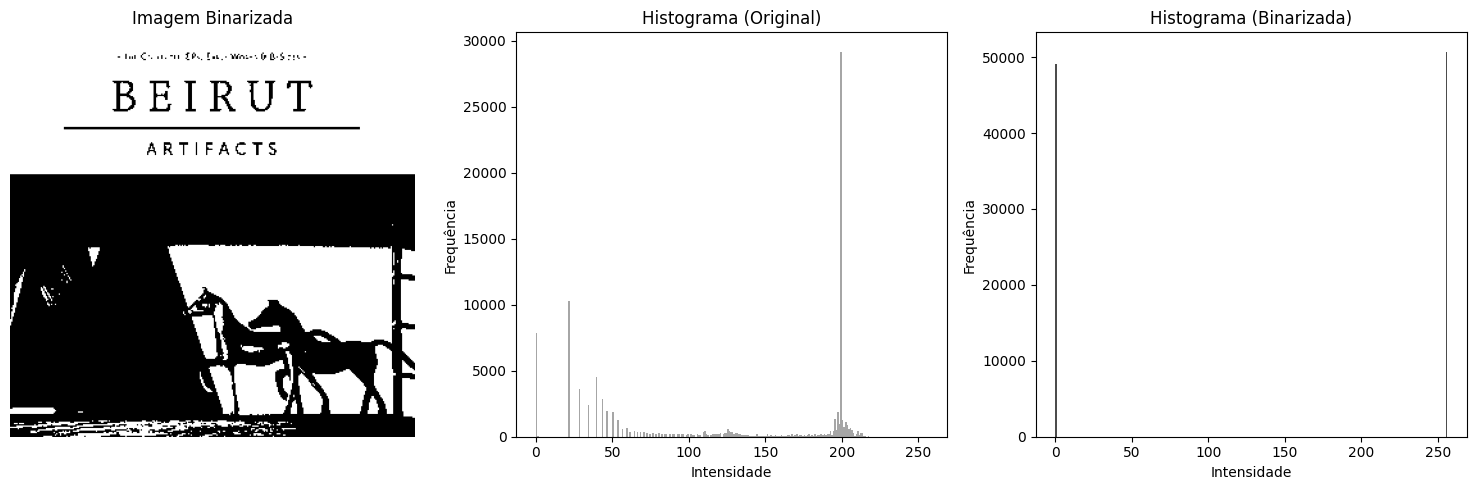

Fração de pixel pretos (0): 0.49190834802115047


In [73]:
T = 128

imagem_nova = imagem.copy()

imagem_nova[imagem < T] = 0
imagem_nova[imagem >= T] = 255

plt_resultados(imagem_nova, imagem)


Método de Otsu

Resultados da binarização:


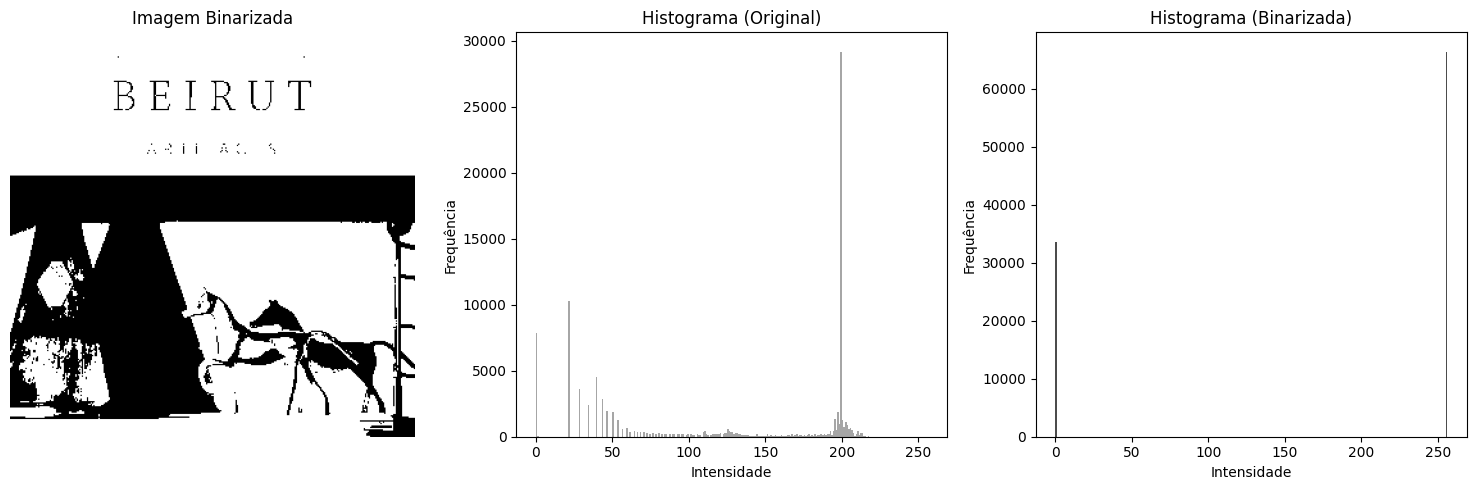

Fração de pixel pretos (0): 0.33532286492549274


In [74]:
hist = cv2.calcHist([imagem], [0], None, [256], [0, 256])
max_var = 0
optimal_threshold = 0
for i in range(255):
    w0 = hist[:i].sum()
    w1 = hist[i:].sum()

    u0 = (hist[:i] * np.arange(i)).sum() / w0 if w0 > 0 else 0
    u1 = (hist[i:] * np.arange(i, 256)).sum() / w1 if w1 > 0 else 0

    var_between = w0 * w1 * (u0 - u1) ** 2
    if var_between > max_var:
        max_var = var_between
        optimal_threshold = i   


imagem_otsu = imagem1.copy()
imagem_otsu[imagem1 < optimal_threshold] = 0
imagem_otsu[imagem1 >= optimal_threshold] = 255


plt_resultados(imagem_otsu, imagem1)

Metodo de Bernsen

Resultados da binarização:


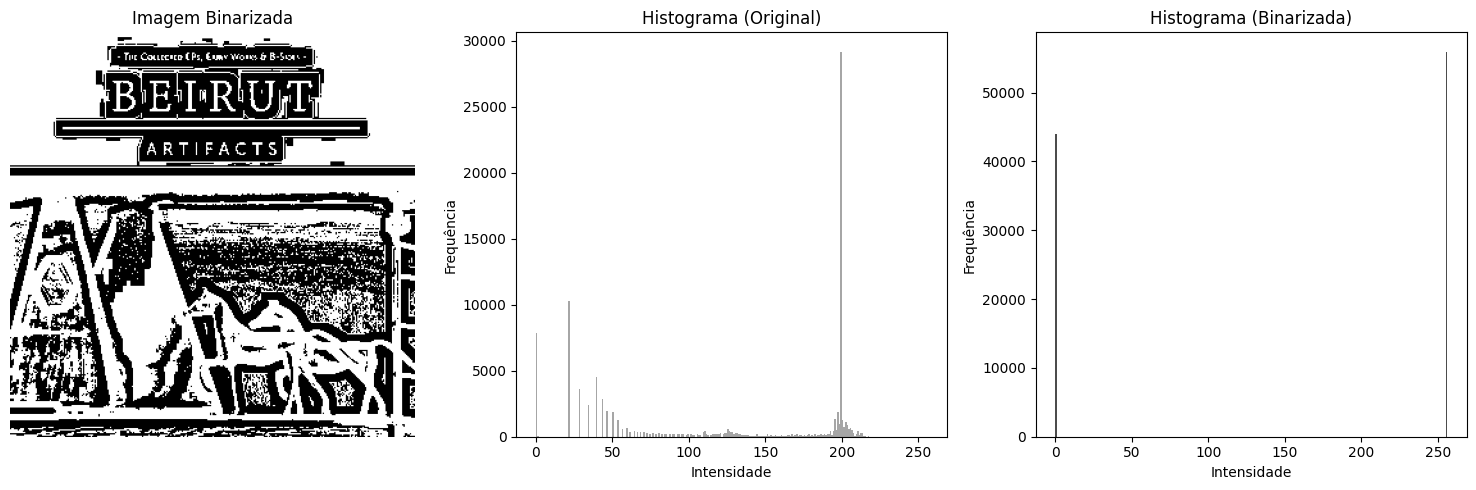

Fração de pixel pretos (0): 0.43976325909309405


In [75]:
imagem_bernsen = imagem1.copy()
n = 11

def bernsen_manual_vetorizado(img, n):
    pad = n // 2
    
    img_padded = np.pad(img, pad_width=pad, mode='reflect')
    
    windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    z_min = np.min(windows, axis=(2, 3)).astype(np.float32)
    z_max = np.max(windows, axis=(2, 3)).astype(np.float32)
    
    T_bernsen = (z_min + z_max) / 2.0
    
    resultado = np.where(img > T_bernsen, 0, 255).astype(np.uint8)
    
    return resultado

imagem_bernsen = bernsen_manual_vetorizado(imagem_bernsen, n)
plt_resultados(imagem_bernsen, imagem1)


Metodo de Niblack 

Resultados da binarização:


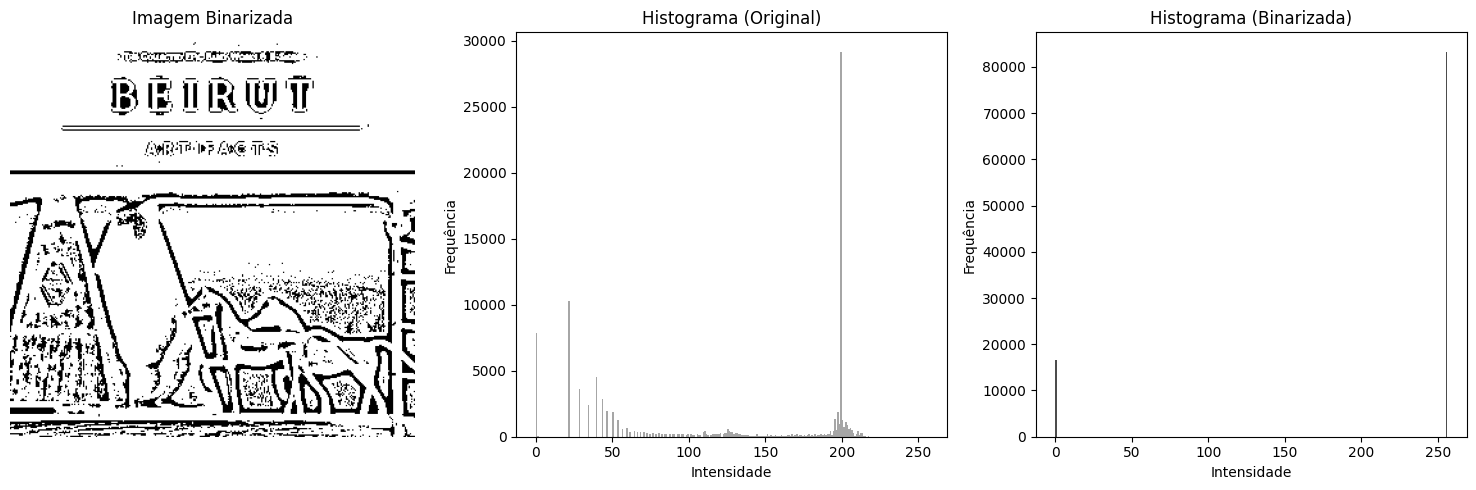

Fração de pixel pretos (0): 0.16587886556641565


In [76]:
imagem_nil = imagem1.copy()
n = 11

def nil_manual_vetorizado(img, n, k):
    pad = n // 2
    img_padded = np.pad(img, pad_width=pad, mode='reflect')
    windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    mean = np.mean(windows, axis=(2, 3)).astype(np.float32)
    std = np.std(windows, axis=(2, 3)).astype(np.float32)
    
    T_nil = mean + std*k
    
    resultado = np.where(img > T_nil, 0, 255).astype(np.uint8)
    
    return resultado

imagem_nil = nil_manual_vetorizado(imagem_nil, n, k=0.5)
plt_resultados(imagem_nil, imagem1)

Metodo de Sauvola e Pietaksinen

Resultados da binarização:


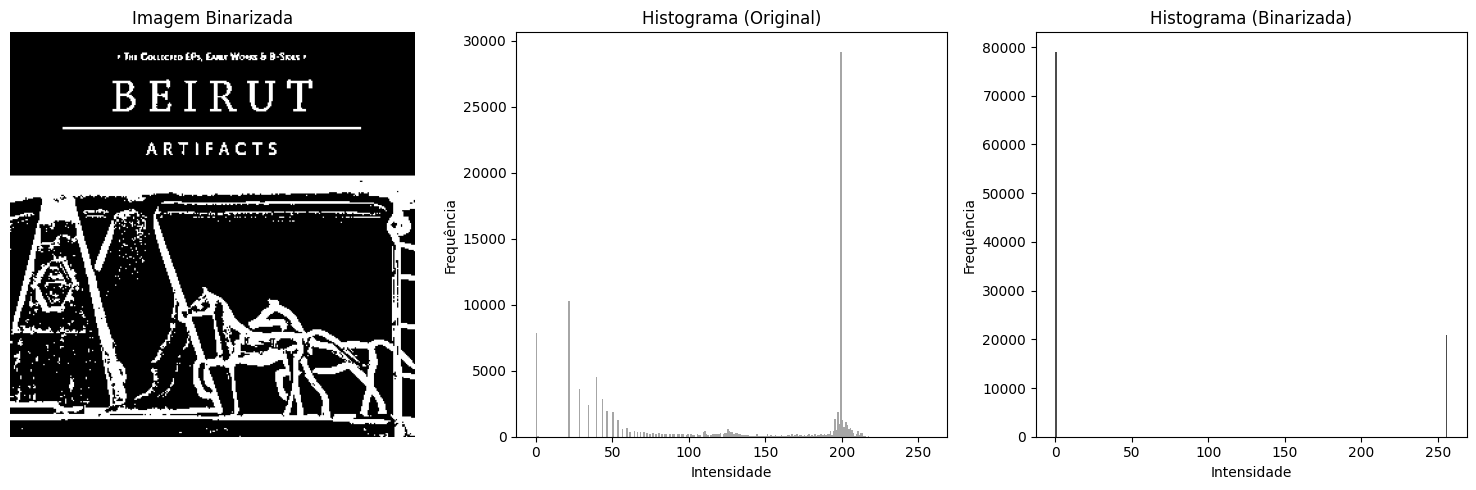

Fração de pixel pretos (0): 0.79187029322224


In [77]:
imagem_SP = imagem1.copy()
n = 11
k = 0.1
R = 128

def SP_manual_vetorizado(img, n, k, R):
    pad = n // 2
    img_padded = np.pad(img, pad_width=pad, mode='reflect')
    windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    mean = np.mean(windows, axis=(2, 3)).astype(np.float32)
    std = np.std(windows, axis=(2, 3)).astype(np.float32)
    
    T_SP = mean * ( 1 + k*(std/R - 1))
    
    resultado = np.where(img > T_SP, 0, 255).astype(np.uint8)
    
    return resultado

imagem_SP = SP_manual_vetorizado(imagem_SP, n, k, R)
plt_resultados(imagem_SP, imagem1)

Metodo de Phansalskar, More e Sabale

Resultados da binarização:


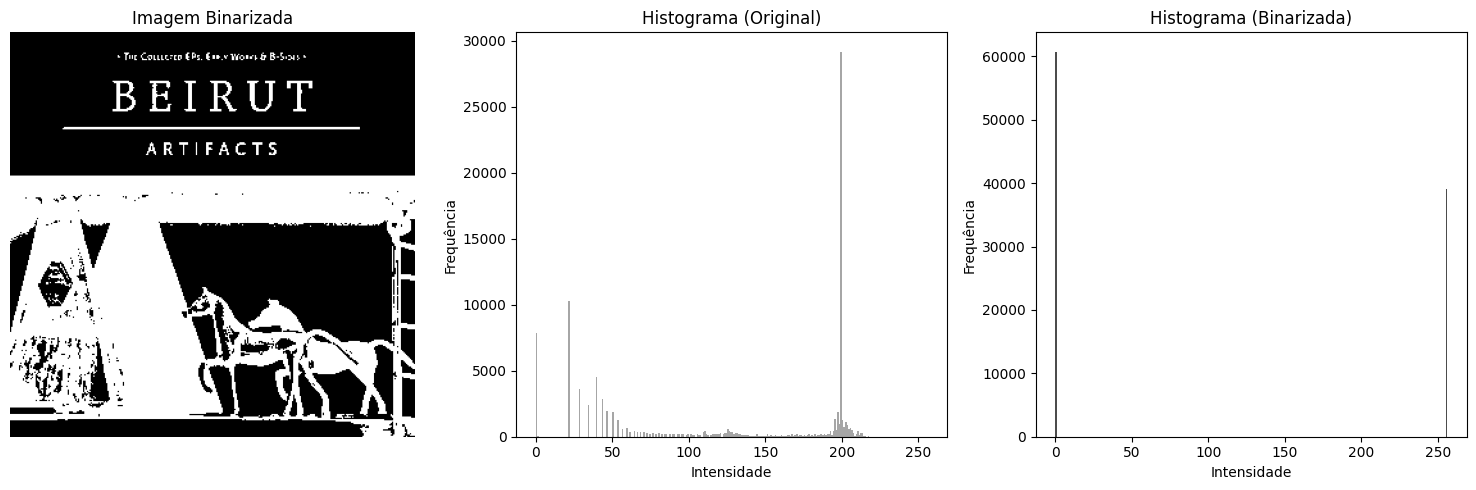

Fração de pixel pretos (0): 0.6084361480531966


In [78]:
imagem_PMS = imagem1.copy()
n = 11
k = 0.25
R = 0.5
q = 10
p = 2

def PMS_manual_vetorizado(img, n, k, R, p, q):

    img_norm = img.astype(np.float32) / 255.0

    pad = n // 2
    img_padded = np.pad(img_norm, pad_width=pad, mode='reflect')
    windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    mean = np.mean(windows, axis=(2, 3)).astype(np.float32)
    std = np.std(windows, axis=(2, 3)).astype(np.float32)
    
    T_PMS = mean * ( 1 + p*np.exp(-q*mean) + k*(std/R - 1))
    
    resultado = np.where(img_norm > T_PMS, 0, 255).astype(np.uint8)
    
    return resultado

imagem_PMS = PMS_manual_vetorizado(imagem_PMS, n, k, R, p ,q)
plt_resultados(imagem_PMS, imagem1)

Metodo do Contraste

Resultados da binarização:


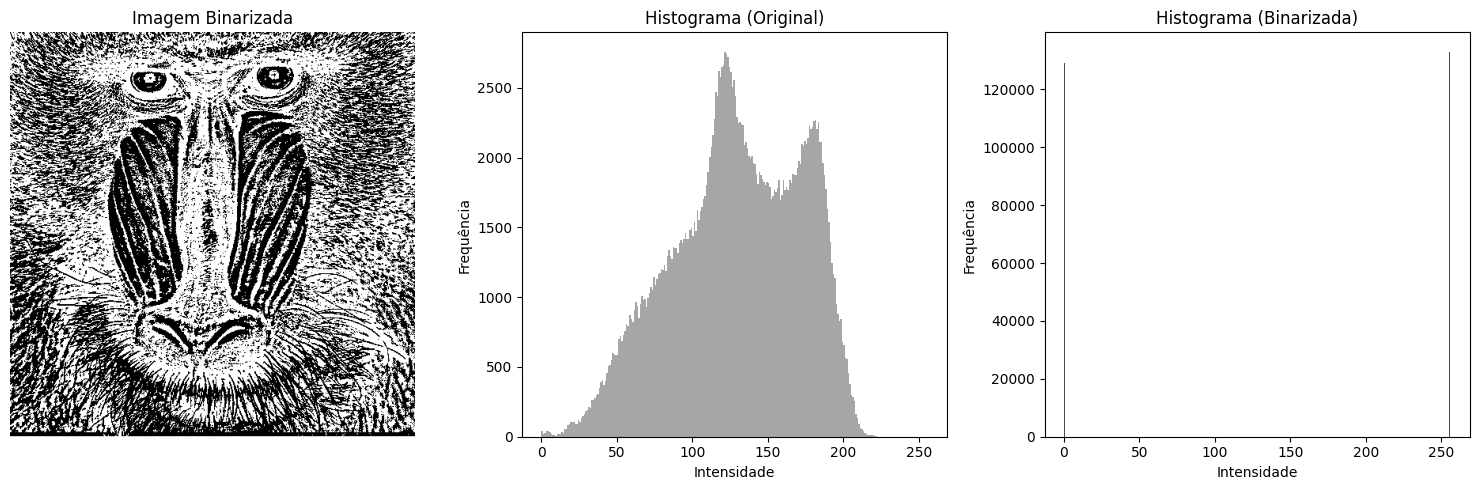

Fração de pixel pretos (0): 0.4923248291015625


In [57]:
imagem_contraste = imagem1.copy()
n = 11

def contraste_manual_vetorizado(img, n):
    pad = n // 2
    img_padded = np.pad(img, pad_width=pad, mode='reflect')
    windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    max = np.max(windows, axis=(2, 3)).astype(np.float32)
    min = np.min(windows, axis=(2, 3)).astype(np.float32)
    i = img.astype(np.float32)
    
    dist_max = max - i
    dist_min = i - min
    
    resultado = np.where(dist_max <= dist_min, 0, 255).astype(np.uint8)
    
    return resultado

imagem_contraste = contraste_manual_vetorizado(imagem_contraste, n)
plt_resultados(imagem_contraste, imagem1)

Metodo da Média

Resultados da binarização:


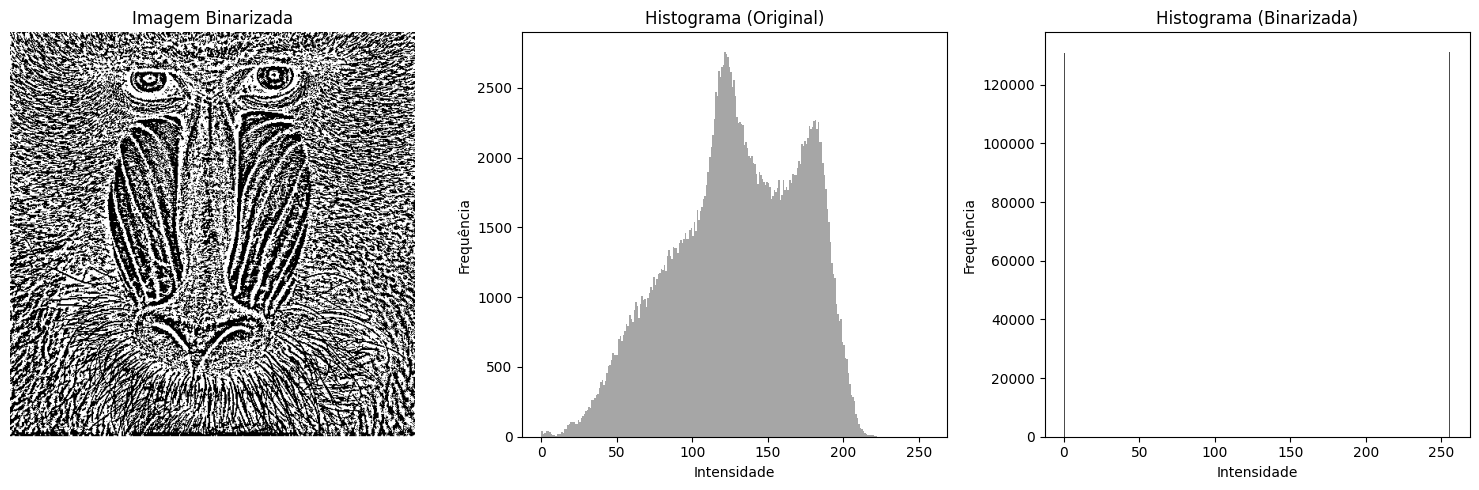

Fração de pixel pretos (0): 0.4992485046386719


In [67]:
imagem_media = imagem1.copy()
n = 11
C = 0.1
def media_manual_vetorizado(img, n, C):
    pad = n // 2
    img_padded = np.pad(img, pad_width=pad, mode='reflect')
    windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    mean = np.mean(windows, axis=(2, 3)).astype(np.float32)
    
    T_mean = mean - C
    resultado = np.where(img > T_mean, 0, 255).astype(np.uint8)
    
    return resultado

imagem_media = media_manual_vetorizado(imagem_media, n, C)
plt_resultados(imagem_media, imagem1)

Método da Mediana

Resultados da binarização:


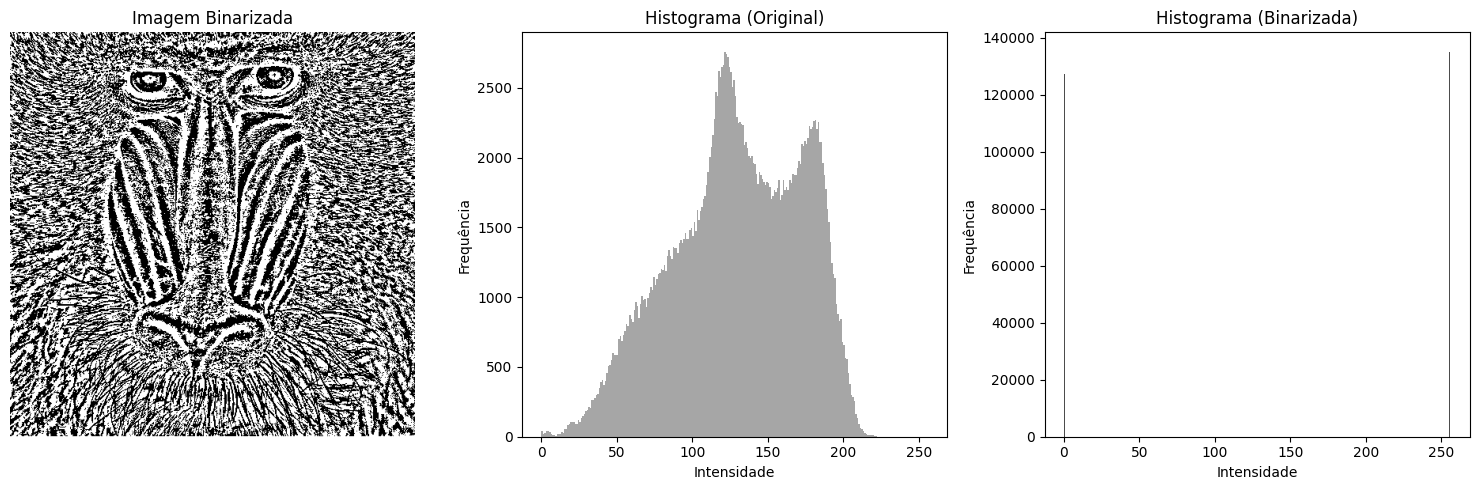

Fração de pixel pretos (0): 0.48473358154296875


In [71]:
imagem_mediana = imagem1.copy()
n = 21
def mediana_manual_vetorizado(img, n):
    pad = n // 2
    img_padded = np.pad(img, pad_width=pad, mode='reflect')
    windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    median = np.median(windows, axis=(2, 3)).astype(np.float32)
    
    T_median = median
    resultado = np.where(img > T_median, 0, 255).astype(np.uint8)
    
    return resultado

imagem_mediana = mediana_manual_vetorizado(imagem_mediana, n)
plt_resultados(imagem_mediana, imagem1)